
# 🧠 Analyse Complète du Dataset : Mental Health Text Classification  
## Projet : Santé Mentale & Réseaux Sociaux

---

### Source
Dataset de classification de textes sur la santé mentale.

### Objectif
Déterminer si ce dataset est adapté pour un projet de classification de troubles mentaux à partir de textes issus des réseaux sociaux.

### Pourquoi cette analyse ?
Avant de choisir un dataset final, il est important d’évaluer :

- sa qualité  
- sa structure  
- son équilibre  
- sa pertinence métier  
- sa compatibilité avec le Machine Learning / Deep Learning

---


---
# 📊 Partie 1 : Exploration et Analyse des Données
---

## 1. Importation des bibliothèques

In [123]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
from wordcloud import WordCloud

plt.style.use('ggplot')

Nous préparons ici tous les outils nécessaires pour explorer les données, créer des visualisations plus attractives et effectuer le prétraitement NLP.

## 2. Chargement du dataset

In [124]:
df = pd.read_csv(r"data.csv")
df

,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety
...,...,...,...
53038,53038,Nobody takes me seriously I’ve (24M) dealt wit...,Anxiety
53039,53039,"selfishness ""I don't feel very good, it's lik...",Anxiety
53040,53040,Is there any way to sleep better? I can't slee...,Anxiety
53041,53041,"Public speaking tips? Hi, all. I have to give ...",Anxiety


## 3. Dimensions du dataset

In [125]:
print("Nombre de lignes :", df.shape[0])
print("Nombre de colonnes :", df.shape[1])

Nombre de lignes : 53043
Nombre de colonnes : 3


## 4. Variables disponibles

In [126]:
print(df.columns)

Index(['Unnamed: 0', 'statement', 'status'], dtype='object')


## 5. Informations générales

In [127]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53043 entries, 0 to 53042
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  53043 non-null  int64 
 1   statement   52681 non-null  object
 2   status      53043 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.2+ MB


On vérifie ici les types de données et la présence éventuelle de valeurs manquantes. Si toutes les colonnes texte sont complètes, cela réduit considérablement le travail de nettoyage.

## 6. Valeurs manquantes

In [128]:
df.isnull().sum()

Unnamed: 0      0
statement     362
status          0
dtype: int64

## supression des valeur null

In [129]:
df = df.dropna()

df.isnull().sum()

Unnamed: 0    0
statement     0
status        0
dtype: int64

## 7. Analyse des doublons

In [130]:
print("Nombre de doublons :", df.duplicated().sum())

Nombre de doublons : 0


## 8. Distribution des classes

In [131]:
df['status'].value_counts()

status
Normal                  16343
Depression              15404
Suicidal                10652
Anxiety                  3841
Bipolar                  2777
Stress                   2587
Personality disorder     1077
Name: count, dtype: int64

Cette étape est extrêmement importante. Elle permet de voir si certaines classes sont surreprésentées. Un dataset déséquilibré peut produire un modèle biaisé.

## 9. Visualisation des classes

/tmp/ipykernel_35335/2120573647.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='status', data=df, palette='viridis')


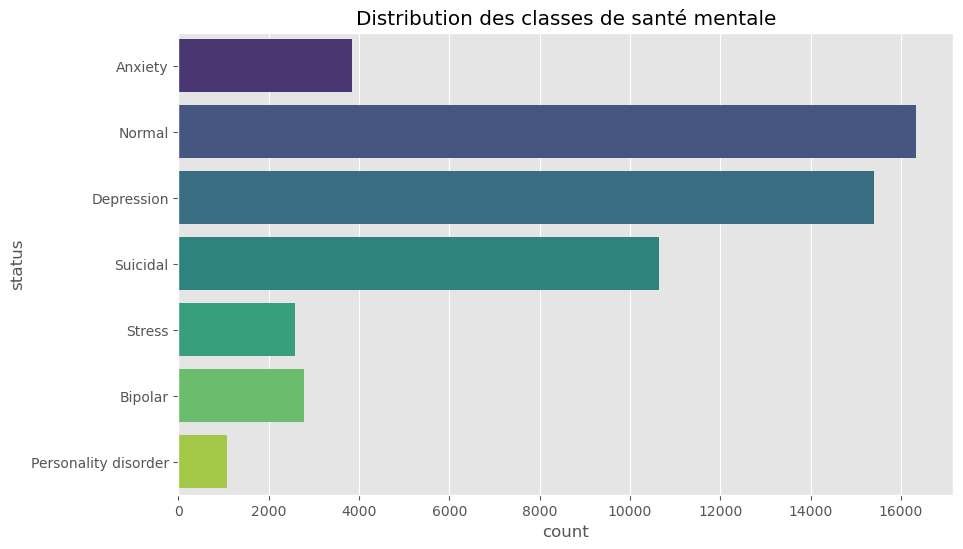

In [132]:
plt.figure(figsize=(10,6))
sns.countplot(y='status', data=df, palette='viridis')
plt.title("Distribution des classes de santé mentale")
plt.show()

Cette visualisation montre clairement quelles pathologies sont dominantes. Si certaines classes sont trop faibles, il faudra envisager du rééquilibrage.

## 10. Longueur des textes

In [133]:
df['longueur_texte'] = df['statement'].astype(str).apply(lambda x: len(x.split()))
df['longueur_texte'].describe()

/tmp/ipykernel_35335/814621924.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['longueur_texte'] = df['statement'].astype(str).apply(lambda x: len(x.split()))


count    52681.000000
mean       113.158729
std        163.735305
min          1.000000
25%         15.000000
50%         62.000000
75%        148.000000
max       6300.000000
Name: longueur_texte, dtype: float64

## 11. Histogramme longueur

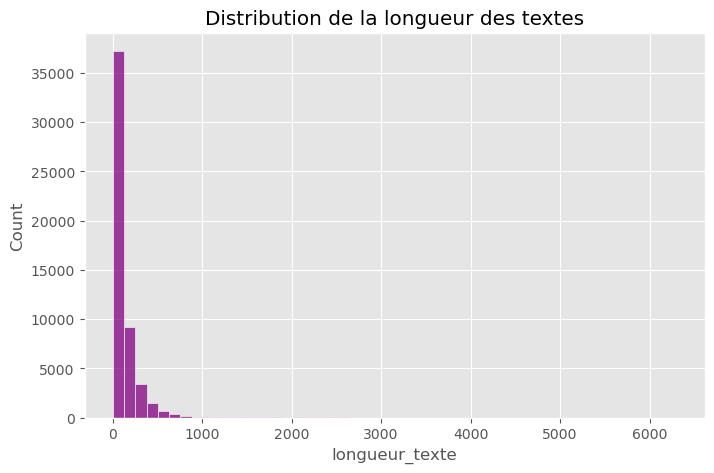

In [134]:
plt.figure(figsize=(8,5))
sns.histplot(df['longueur_texte'], bins=50, color='purple')
plt.title("Distribution de la longueur des textes")
plt.show()

In [135]:
# distrubution du longueur du text par rapport a la classe

Average word count per class:
 status
Normal                   17.246283
Stress                  114.585234
Anxiety                 143.837022
Suicidal                146.440293
Depression              168.021488
Bipolar                 176.200216
Personality disorder    179.346332
Name: word_count, dtype: float64


/tmp/ipykernel_35335/245345671.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['word_count'] = df['statement'].apply(lambda x: len(x.split()))


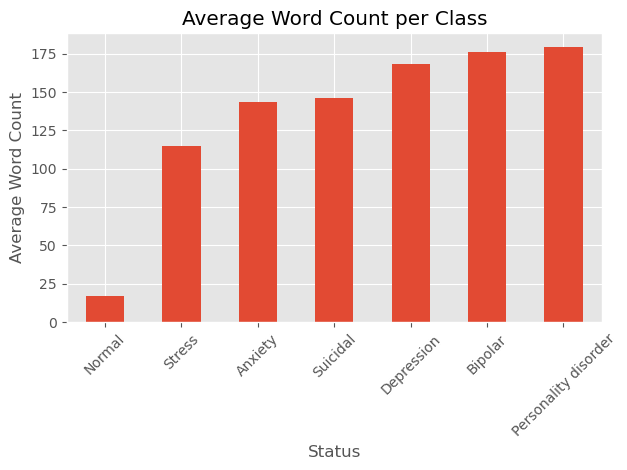

<Figure size 640x480 with 0 Axes>

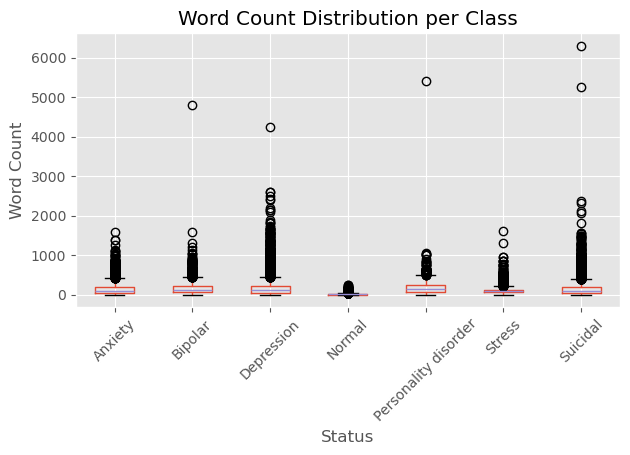

In [136]:

df['word_count'] = df['statement'].apply(lambda x: len(x.split()))



avg_word_count = df.groupby('status')['word_count'].mean().sort_values()

print("Average word count per class:\n", avg_word_count)



plt.figure()
avg_word_count.plot(kind='bar')

plt.title('Average Word Count per Class')
plt.xlabel('Status')
plt.ylabel('Average Word Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



plt.figure()
df.boxplot(column='word_count', by='status')

plt.title('Word Count Distribution per Class')
plt.suptitle('')  # remove default pandas title
plt.xlabel('Status')
plt.ylabel('Word Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Une distribution relativement homogène est préférable pour entraîner des modèles NLP plus stables.

## 13. Mots fréquents

In [137]:
all_words = " ".join(df['statement'])
freq = Counter(all_words.split())

common_words = pd.DataFrame(freq.most_common(20), columns=['Mot','Fréquence'])
common_words

,Mot,Fréquence
0,I,319524
1,to,193910
2,and,169077
3,the,119388
4,a,115565
5,my,109073
6,of,83995
7,i,79599
8,not,72618
9,is,68692


Les mots les plus fréquents permettent d’identifier les thèmes dominants : stress, anxiété, dépression, etc.

## 14. Visualisation mots fréquents

/tmp/ipykernel_35335/1795140947.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Fréquence', y='Mot', data=common_words, palette='magma')


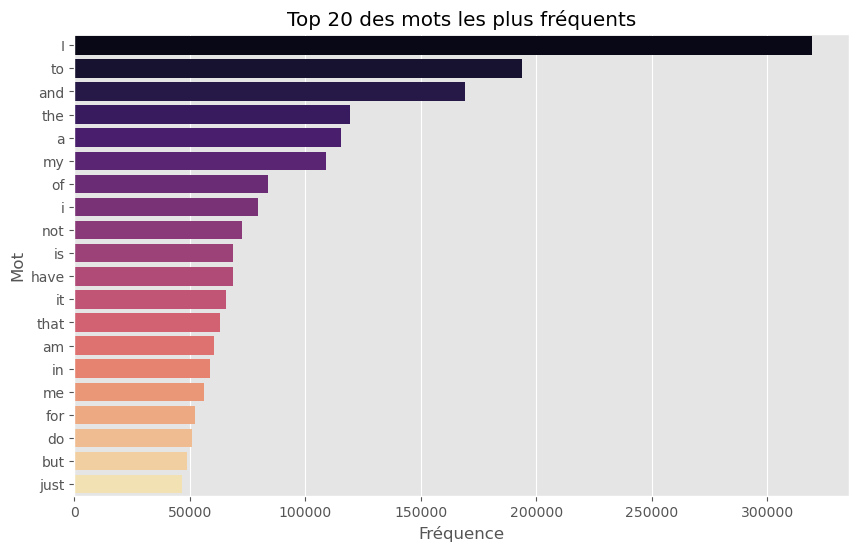

In [138]:
plt.figure(figsize=(10,6))
sns.barplot(x='Fréquence', y='Mot', data=common_words, palette='magma')
plt.title("Top 20 des mots les plus fréquents")
plt.show()

Cette visualisation donne une lecture rapide des expressions les plus présentes dans les conversations.

## 16. Tableau final d’évaluation

In [139]:
evaluation = pd.DataFrame({
    'Critère':[
        'Taille dataset',
        'Qualité des données',
        'Labels structurés',
        'Compatibilité Machine Learning',
        'Compatibilité Deep Learning',
        'Pertinence projet santé mentale'
    ],
    'Évaluation':[
        'Très bonne',
        'Bonne',
        'Oui',
        'Excellente',
        'Très bonne',
        'Très élevée'
    ]
})
evaluation

,Critère,Évaluation
0,Taille dataset,Très bonne
1,Qualité des données,Bonne
2,Labels structurés,Oui
3,Compatibilité Machine Learning,Excellente
4,Compatibilité Deep Learning,Très bonne
5,Pertinence projet santé mentale,Très élevée


---
# 🔠 Partie 2 : Encodage des Variables
---

In [140]:
## ENCODAGE DE VARIABLE STATUS

In [141]:
df["status"] = df["status"].map({"Depression": 1, "Normal": 0})


/tmp/ipykernel_35335/2599933787.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["status"] = df["status"].map({"Depression": 1, "Normal": 0})


In [142]:
df = df[df["status"].isin([0, 1])]

In [143]:
df

,Unnamed: 0,statement,status,longueur_texte,word_count
733,733,"Gr gr dreaming of ex crush to be my game, God",0.0,11,11
734,734,wkwkwk what a joke,0.0,4,4
735,735,Leaves are also standby in front of the PC ......,0.0,18,18
736,736,Thank God even though it's just a ride through,0.0,9,9
737,737,wedding teaser concept using the song day6 - o...,0.0,13,13
...,...,...,...,...,...
48283,48283,"solutions So, when I have my real bad downs th...",1.0,113,113
48284,48284,I’m pretty sure I’m depressed.. Ive been feeli...,1.0,24,24
48285,48285,I can’t be bothered anymore. I’m a 22 year old...,1.0,472,472
48286,48286,Depression feels like you’re drowning and ther...,1.0,17,17


---
# 🧹 Partie 3 : Prétraitement du Texte (NLP)
---

In [36]:
#contraction expantion 

In [144]:
def expand_contractions(text, contractions):
    words = text.split()
    new_words = []

    for word in words:
        if word in contractions:
            new_words.append(contractions[word])
        else:
            new_words.append(word)

    return " ".join(new_words)

    
    
import re
import contractions


def clean_data(text):
    text = str(text)

    # 0. normalize apostrophes
    text = text.replace("’", "'")

    # 1. lowercase
    text = text.lower()

    text = contractions.fix(text)

    # 3. replace names
    text = re.sub(r'@\w+', ' <name> ', text)

    # 4. replace numbers
    text = re.sub(r'\d+', ' <number> ', text)

    # 5. remove punctuation except ?, ! and '
    text = re.sub(r"[^\w\s?!]", "", text)

    return text

df["cleaned_statement"] = df["statement"].apply(clean_data)


# tokenisation

In [149]:
from nltk.tokenize import word_tokenize

df['tokens'] = df['cleaned_statement'].apply(word_tokenize)

In [150]:
df

,Unnamed: 0,statement,status,longueur_texte,word_count,cleaned_statement,tokens
733,733,"Gr gr dreaming of ex crush to be my game, God",0.0,11,11,gr gr dreaming of ex crush to be my game god,"[gr, gr, dreaming, of, ex, crush, to, be, my, ..."
734,734,wkwkwk what a joke,0.0,4,4,wkwkwk what a joke,"[wkwkwk, what, a, joke]"
735,735,Leaves are also standby in front of the PC ......,0.0,18,18,leaves are also standby in front of the pc be...,"[leaves, are, also, standby, in, front, of, th..."
736,736,Thank God even though it's just a ride through,0.0,9,9,thank god even though it is just a ride through,"[thank, god, even, though, it, is, just, a, ri..."
737,737,wedding teaser concept using the song day6 - o...,0.0,13,13,wedding teaser concept using the song day numb...,"[wedding, teaser, concept, using, the, song, d..."
...,...,...,...,...,...,...,...
48283,48283,"solutions So, when I have my real bad downs th...",1.0,113,113,solutions so when i have my real bad downs the...,"[solutions, so, when, i, have, my, real, bad, ..."
48284,48284,I’m pretty sure I’m depressed.. Ive been feeli...,1.0,24,24,i am pretty sure i am depressed i have been fe...,"[i, am, pretty, sure, i, am, depressed, i, hav..."
48285,48285,I can’t be bothered anymore. I’m a 22 year old...,1.0,472,472,i cannot be bothered anymore i am a number y...,"[i, can, not, be, bothered, anymore, i, am, a,..."
48286,48286,Depression feels like you’re drowning and ther...,1.0,17,17,depression feels like you are drowning and the...,"[depression, feels, like, you, are, drowning, ..."


## Lemitasation 


In [151]:
import nltk
from nltk.stem import WordNetLemmatizer

# download if not already done
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')

import nltk
from nltk import pos_tag
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return 'a'  # adjective
    elif tag.startswith('V'):
        return 'v'  # verb
    elif tag.startswith('N'):
        return 'n'  # noun
    elif tag.startswith('R'):
        return 'r'  # adverb
    else:
        return 'n'

def lemmatize_tokens(tokens):
    tagged = pos_tag(tokens)
    return [lemmatizer.lemmatize(word, get_wordnet_pos(tag)) for word, tag in tagged]

df['tokens'] = df['tokens'].apply(lemmatize_tokens)
df["cleaned_statement"] = df["tokens"].apply(lambda x: " ".join(x))

[nltk_data] Downloading package punkt to /home/mohamed/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /home/mohamed/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/mohamed/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [155]:
df

,Unnamed: 0,statement,status,longueur_texte,word_count,cleaned_statement,tokens
733,733,"Gr gr dreaming of ex crush to be my game, God",0.0,11,11,gr gr dreaming of ex crush to be my game god,"[gr, gr, dreaming, of, ex, crush, to, be, my, ..."
734,734,wkwkwk what a joke,0.0,4,4,wkwkwk what a joke,"[wkwkwk, what, a, joke]"
735,735,Leaves are also standby in front of the PC ......,0.0,18,18,leaf be also standby in front of the pc becaus...,"[leaf, be, also, standby, in, front, of, the, ..."
736,736,Thank God even though it's just a ride through,0.0,9,9,thank god even though it be just a ride through,"[thank, god, even, though, it, be, just, a, ri..."
737,737,wedding teaser concept using the song day6 - o...,0.0,13,13,wed teaser concept use the song day number onl...,"[wed, teaser, concept, use, the, song, day, nu..."
...,...,...,...,...,...,...,...
48283,48283,"solutions So, when I have my real bad downs th...",1.0,113,113,solution so when i have my real bad down there...,"[solution, so, when, i, have, my, real, bad, d..."
48284,48284,I’m pretty sure I’m depressed.. Ive been feeli...,1.0,24,24,i be pretty sure i be depress i have be feel t...,"[i, be, pretty, sure, i, be, depress, i, have,..."
48285,48285,I can’t be bothered anymore. I’m a 22 year old...,1.0,472,472,i can not be bother anymore i be a number year...,"[i, can, not, be, bother, anymore, i, be, a, n..."
48286,48286,Depression feels like you’re drowning and ther...,1.0,17,17,depression feel like you be drown and there be...,"[depression, feel, like, you, be, drown, and, ..."


---
# ✂️ Partie 4 : Séparation du Dataset (Train / Test)
---

In [ ]:
##separer dataset

In [157]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df['cleaned_statement'],
    df['status'],
    test_size=0.2,
    random_state=42
)

---
# 🔢 Partie 5 : Vectorisation (TF-IDF)
---

In [158]:
# vectorisation

In [159]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer()

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

---
# 🤖 Partie 6 : Modélisation Machine Learning
---

## Regression lineare  

In [169]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.model_selection import StratifiedKFold, cross_val_score

model = LogisticRegression(
    class_weight='balanced'
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X_train_tfidf, y_train, cv=cv, scoring='f1_macro')

In [171]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report

y_pred = cross_val_predict(model, X_test_tfidf, y_test, cv=cv)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.91      0.95      0.93      3255
         1.0       0.95      0.90      0.92      3095

    accuracy                           0.92      6350
   macro avg       0.93      0.92      0.92      6350
weighted avg       0.92      0.92      0.92      6350



## SVM 

In [178]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold

svm = SVC(class_weight='balanced')

param_grid = {
    "C": [0.1, 1, 10],
    "kernel": ["linear"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1
)
grid.fit(X_train_tfidf, y_train)

,estimator,SVC(class_weight='balanced')
,param_grid,"{'C': [0.1, 1, ...], 'kernel': ['linear']}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,1


In [179]:
print("Best parameters:", grid.best_params_)
print("Best F1-score:", grid.best_score_)

Best parameters: {'C': 1, 'kernel': 'linear'}
Best F1-score: 0.9517632016306953


In [180]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report

y_pred_svm = cross_val_predict(grid, X_test_tfidf, y_test, cv=cv)

print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

         0.0       0.92      0.95      0.94      3255
         1.0       0.95      0.92      0.93      3095

    accuracy                           0.93      6350
   macro avg       0.93      0.93      0.93      6350
weighted avg       0.93      0.93      0.93      6350



## 17. Conclusion finale